In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = [1, 2, 3, 4, 5]
y = [3, 6, 11, 18, 27]

In [3]:
class PolynomialRegression:
    """
    Polynomial Regression model trained using Batch Gradient Descent.

    This implementation expands a single input feature into polynomial
    features up to the specified degree and fits the model by minimizing
    the Mean Squared Error (MSE).

    Attributes:
        x (array-like): ndarray of shape (n_samples,)Training input data.
        y (array-like): ndarray of shape (n_samples,)Training target values.
        degree (int)  : The maximum polynomial degree.
        w  (ndarray ):of shape (degree + 1,)Model weights including bias term (w[0])
        alpha (float): Learning rate used during training.
        num_iteration (int): Number of gradient descent iterations.
        sse_value (list of float):Sum of Squared Errors recorded at each iteration.
    """
    def __init__(self,x,y,degree):
        """ 
        Constructor to initialize input features and target.

        Parameters:
        x (array-like): Input feature(s), shape (n_samples,) or (n_samples, n_features).
        y (array-like): Target values, shape (n_samples,).
        degree (int)  : The maximum polynomial degree.

        """
        self.x=np.array(x)
        self.y=np.array(y)
        self.degree=degree


    def fit_transform(self,alpha,num_iteration):
        """
    Trains the polynomial regression model using batch gradient descent.

    Parameters
    ----------
    alpha : float
        Learning rate controlling the step size of weight updates.

    num_iteration : int
        Number of iterations for gradient descent.

    Updates
    -------
    self.w : ndarray
        Learned model weights (including bias term).

    self.sse_value : list
        Stores the Sum of Squared Errors (SSE) at each iteration.

        """
        self.w = np.zeros(self.degree+1)
        x_p  = self.transform(self.x)
        self.alpha = alpha
        self.num_iteration= num_iteration
        n = x_p.shape[0]
        self.sse_value= []
        for i in range(self.num_iteration):
            y_hat = np.dot(x_p,self.w)

            D_w = (2/n) * np.dot(x_p.T, (y_hat - self.y))
            
            self.w -=  self.alpha * D_w
            
            sse = (np.sum((y_hat-self.y)**2))
            self.sse_value.append(sse)


    def transform(self,x):
            """
    Expands input feature into polynomial feature matrix.

    Generates a design matrix including:
        - Column 0 → Bias term (all ones)
        - Column 1 → x
        - Column 2 → x^2
        - ...
        - Column degree → x^degree

    Parameters
    ----------
    x : array-like of shape (n_samples,)
        Input feature values.

    Returns
    -------
    ndarray of shape (n_samples, degree + 1)
    Polynomial feature matrix.

    """
            x = np.array(x).reshape(-1)            
            n = x.shape[0]
            x_transformed = np.ones((n, self.degree + 1))
            for j in range(1,self.degree+1):
                        x_transformed[:,j]  = x ** j
            return x_transformed          


    def predict(self,new_x):
            """
    Predicts target values for new input data.

    Parameters
    ----------
    new_x : array-like of shape (n_samples,)
        New input feature values.

    Returns
    -------
    ndarray of shape (n_samples,)
        Predicted target values.
            """
            X_poly = self.transform(new_x)
            return np.dot(X_poly, self.w)  


    def visualize(self):    
            """
            Visualizes training results.

            Plots:
            1. SSE (Sum of Squared Errors) over iterations.
            2. Polynomial regression curve fitted to the training data.
            """
            plt.figure(figsize=(13,2))
            plt.subplot(1,2,1)
            plt.plot(range(self.num_iteration) , self.sse_value, label='sse')
            plt.xlabel("Iteration")
            plt.ylabel("SSE")
            plt.title("SSE over Iteration")
            plt.legend()
            plt.subplot(1,2,2)
            plt.scatter(self.x,self.y,color="blue",label="Data point")
            x_sorted = np.sort(self.x)
            y_pred = self.predict(x_sorted)
            plt.plot(x_sorted, y_pred, color="red",label="Polynomial Regression")
            plt.xlabel("X")
            plt.ylabel("Y")
            plt.title("Polynomial Regression fit line")
            plt.show()


    def calc_MSE(self):
        """
        Calculates Mean Squared Error (MSE) of the model on training data.

        Returns:
        float: Mean Squared Error.
        """
        X_poly = self.transform(self.x)
        y_hat = np.dot(X_poly, self.w)      
        mse = np.mean((self.y - y_hat) ** 2)
        return mse


    def calc_RMSE(self):
        """
        Calculates Root Mean Squared Error (RMSE) of the model on training data.

        Returns:
        float: Root Mean Squared Error.
        """
        return np.sqrt(self.calc_MSE())


    def calc_R2Score(self):
            """
            Calculates the R-squared (coefficient of determination) of the model.

            Returns:
            float: R² score, indicates how well the model explains variance in y.
            """
            X_poly = self.transform(self.x)
            y_hat = np.dot(X_poly, self.w)  
            sse = np.sum((self.y - y_hat) ** 2)
            sst = np.sum((self.y - np.mean(self.y)) ** 2)
            r2  = 1 - (sse / sst)
            return r2



In [4]:
l5 = PolynomialRegression(x, y, 2)
l5.fit_transform(0.0001, 10000)

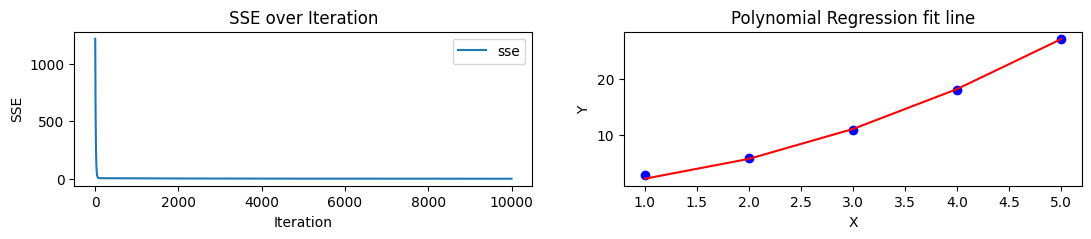

In [5]:
l5.visualize()

In [6]:
print("Prediction for 3:", l5.predict(3))
print("MSE:", l5.calc_MSE())
print("RMSE:", l5.calc_RMSE())
print("R2:", l5.calc_R2Score())

Prediction for 3: [11.11509996]
MSE: 0.09114835912946459
RMSE: 0.3019078652991084
R2: 0.9987814390490714
